# Prepare pitch tracks

Queries and reference songs are already on disk under `data/queries/` and `data/references/` (see `data/queries_index.csv` for the query -> song mapping). This notebook isolates each song's vocals with Demucs and extracts pYIN pitch tracks for both queries and references, caching everything under `.cache/`.

In [1]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
import plots, utils
from tqdm.auto import tqdm

PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442", "#000000"]
plots.set_style(PALETTE)

DATA_ROOT = Path("data")
CACHE_ROOT = Path(".cache")
PITCH = {"sr": 22050, "fmin": 80.0, "fmax": 1000.0, "frame_length": 2048, "hop_seconds": 0.025}

In [2]:
index = pd.read_csv(DATA_ROOT / "queries_index.csv")
print(len(index), "queries across", index.song_id.nunique(), "songs")
index.head()

86 queries across 55 songs


,query_id,song_id,title,original_artist,path
0,q1,1118,Mother natures son,The Beatles,queries/q1.wav
1,q3,1546,Stairway to heaven,Led Zeppelin,queries/q3.wav
2,q4,1579,Strawberry fields forever,The Beatles,queries/q4.wav
3,q5,1808,When I am sixty four,The Beatles,queries/q5.wav
4,q6,2133,More than words,Extreme,queries/q6.wav


## Query pitch tracks

In [3]:
query_cache = CACHE_ROOT / "pitch" / "queries"
query_tracks = utils.extract_f0_batch(DATA_ROOT / index.path, query_cache, PITCH)
len(query_tracks)

pYIN:   0%|          | 0/86 [00:00<?, ?it/s]

86

## Reference pitch tracks

Each song in `data/references/` is a full official-audio mix, so its vocals are isolated with Demucs before pYIN is run on the isolated stem.

In [4]:
songs = index.drop_duplicates("song_id")[["song_id", "title", "original_artist"]]
demucs_cache = CACHE_ROOT / "demucs"
ref_cache = CACHE_ROOT / "pitch" / "references"

reference_vocals = {}
for row in tqdm(list(songs.itertuples()), desc="separating vocals"):
    song_path = DATA_ROOT / "references" / f"{row.song_id}.wav"
    reference_vocals[row.song_id] = utils.separate_vocals(song_path, demucs_cache)

ref_tracks = {sid: utils.extract_f0(path, ref_cache / str(sid), PITCH)
              for sid, path in tqdm(reference_vocals.items(), desc="pYIN (references)")}
len(ref_tracks)

separating vocals:   0%|          | 0/55 [00:00<?, ?it/s]

pYIN (references):   0%|          | 0/55 [00:00<?, ?it/s]

55

## Data quality: voiced-frame fraction

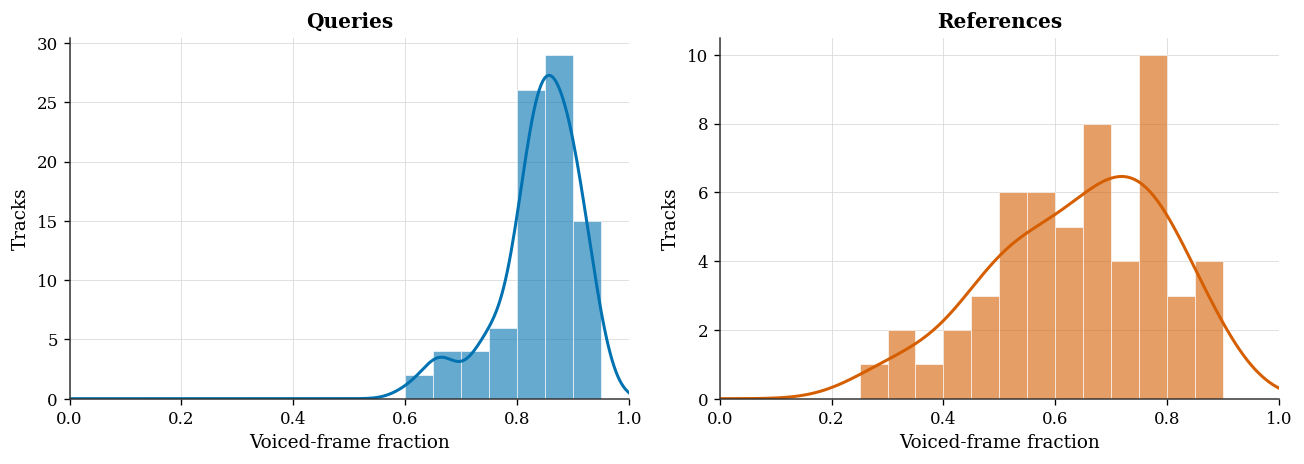

In [5]:
query_voiced = [np.mean(~np.isnan(f0)) for _, f0 in query_tracks.values()]
ref_voiced = [np.mean(~np.isnan(f0)) for _, f0 in ref_tracks.values()]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plots.plot_voiced_fraction_hist(axes[0], query_voiced, title="Queries", color=PALETTE[0])
plots.plot_voiced_fraction_hist(axes[1], ref_voiced, title="References", color=PALETTE[1])
fig.tight_layout()

## Sanity check: a query and its reference

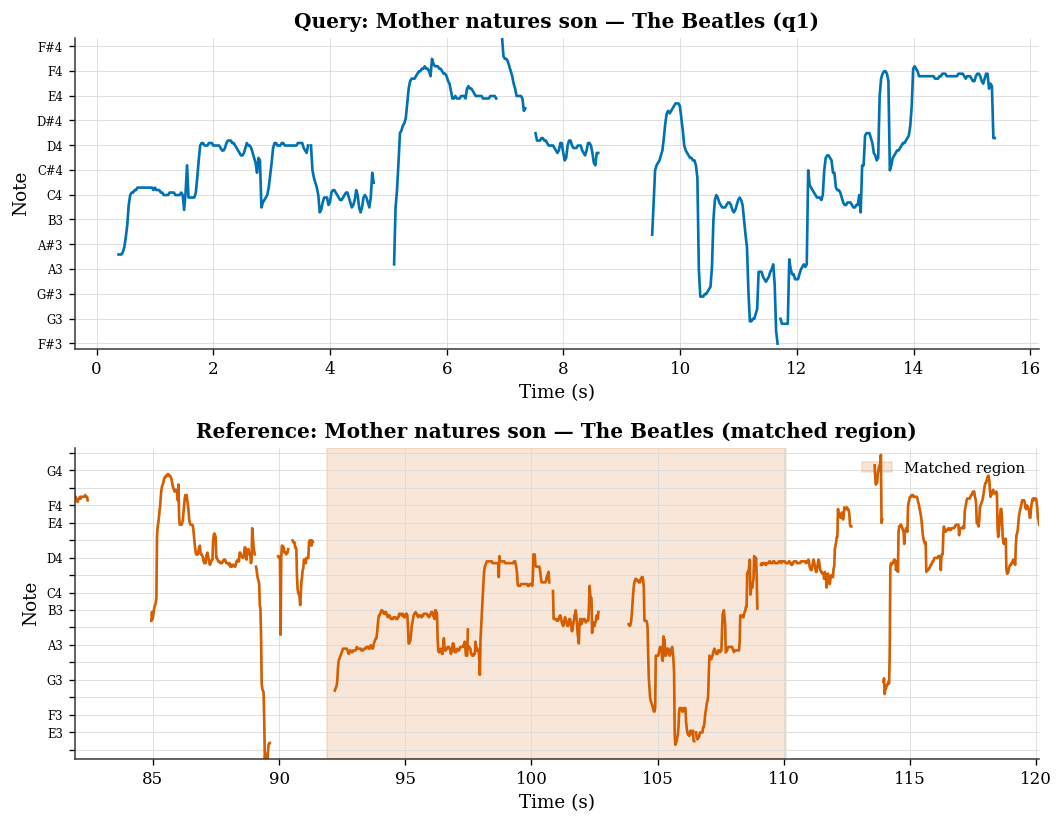

In [6]:
row = index.iloc[0]
qt = query_tracks[row.query_id]
rt = ref_tracks[row.song_id]

MATCH = {"hop_seconds": 0.1, "f_ref": 55.0, "n_classes": 24, "shift_step": 2}
q_cents = utils.downsampled_cents(qt, MATCH, PITCH)
r_cents = utils.downsampled_cents(rt, MATCH, PITCH)
q_prof = utils.to_pitch_class_profile(q_cents, MATCH["n_classes"], sigma_cents=50)
r_prof = utils.to_pitch_class_profile(r_cents, MATCH["n_classes"], sigma_cents=50)
_, start_frame, end_frame = utils.transposed_subsequence_match(q_prof, r_prof, MATCH["n_classes"], "cityblock", MATCH["shift_step"])
match_span = (start_frame * MATCH["hop_seconds"], end_frame * MATCH["hop_seconds"])

pad_seconds = 10.0
view_start = max(rt[0][0], match_span[0] - pad_seconds)
view_end = min(rt[0][-1], match_span[1] + pad_seconds)

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
plots.plot_f0(axes[0], *qt, title=f"Query: {row.title} — {row.original_artist} ({row.query_id})", color=PALETTE[0])
plots.plot_f0(axes[1], *rt, title=f"Reference: {row.title} — {row.original_artist} (matched region)",
              color=PALETTE[1], highlight=match_span, xlim=(view_start, view_end))
fig.tight_layout()